# Group Project 2 "Forced Response Prediction" Exercise Sheet

Group N: Jane Doe, John Doe, James Doe **<- Enter your group number / name here**

Welcome to the lovely home of your group project for this years' *Introduction to Advanced Data Analytics* Lecture. This is the place where you find all information regarding your group project, and also the place to work on your group project. You will submit a copy of this file in the end.

## Project description

You are working in groups of max. 3 people. Each group will get assigned, at random, a dataset and a method that was discussed during the lecture. The datasets are coming from the Earth System Science, and are taken from real-world research problems. Your task is to use the two methods you were assigned (one linear and one nonlinear statistical learning method) to fit and predict from the dataset you have been given. For the prediction, you will be given a part of the dataset consisting only of predictors but with target values omitted. For comparing your methods, you will also fit a multiple linear regression model (without any regularisation) to the dataset.

The methods you have been assigned may or may not be suitable one for the dataset. However, the final performance of your code, that is the precision of your prediction, is not important. The key goal is to show that 

1. you understand the theoretical background of what a specific method is doing or attempts to do;
2. you are aware of the strengths and limitations of a given method applied to a concrete atmospheric science problem;
3. you are able to correctly apply the method in a training/testing context (e.g., cross-validation, hyperparameter selection, etc.);
4. you are able to interpret the results of your method application to the atmospheric science problem.

Below we have already constructed a framework that helps you through data reading and preparation, gives you space for model fitting and prediction and in the end asks you the questions you need to work on. So you just need to work along the framework and make sure you carefully answer each question, and then you can hand in!

## Method and Data

The pool of methods consists of

| Method | R packages | Function/Help |
| :- | :- | :- |
| Backward subset selection | `leaps` | `?regsubsets` |
| Principal component regression | `pls` | `?pcr` |
| Ridge Regression | `glmnet` | `?glmnet` |
| Lasso Regression | `glmnet` | `?glmnet` |
| Multivariate adaptive regression splines | `earth` | `?earth` |
| Random Forest | `randomForest` | `?randomForest` |
| Boosted Trees | `gbm` | `?gbm` |

NB: 
- You will be working with one linear and one non-parametric method from the method pool above. Please find on Moodle which of the methods is assigned to you.
- You can follow the coding style from the exercises to implement your method. Use the help function (e.g. `?regsubsets`) to familiarize yourself with your methods and how to implement them.
- In some cases, you will have to reduce the number of predictors to make it work with resource-demanding methods. 


And this is the dataset you'll be working with:


2. **Estimation of the state of forced climate change from annual temperature maps** <br>
Internal atmospheric variability affects the climate system at all temporal and spatial scales. Therefore, detecting externally forced climate change from maps of (for example) annual temperatures is not straightforward. In fact, there will be always inescapable uncertainty around how much a certain climate state is made up of internal variability and externally forced change, as we only observe a combination of the two.

    The goal of the present project is to estimate two target metrics that describe the state of externally forced climate from global annual temperature maps, using statistical learning methods. The two target metrics are the forced global mean temperature response ($F_T$), in °C, a vector of length $n$ equal to the number of training samples), and the year from which a certain annual temperature map comes from ($F_Y$). This type of statistical learning based climate change detection is indeed used in current climate research (see Barnes et al. 2019; Sippel et al. 2020 for a more detailed description of this idea). We’ll estimate both metrics from annual global temperature maps ($X$), matrices of $n$ $x$ $p$, where $n$ is the number of training samples, and $p$ is the number of grid cell predictors, here $p=2592$). Hence, our goal is to estimate a function $f$ in order to derive a prediction $\hat{F}$ using a relationship of the form $F=f(X)+ \epsilon$.

    For this project, we will make use of an ensemble of climate model simulations. Our ensemble is made up of seven different climate models ("CanESM2", "CESM1-CAM5", "CSIRO-Mk3-6-0", "EC-EARTH", "GFDL-CM3", "GFDL-ESM2M", "MPI-ESM"), and each climate model contains ten simulations up to the year 2030 that we can use for training our statistical learning model. In the case of these model simulations (and in contrast to observed climate data), we know metrics of forced climate change ($F_T$, $F_Y$), because the ensemble average across a large number of simulations reveals forced (=systematic) changes, whereas individual members show (partly large) internal variability on top of a systematic forced change.

    A simple illustration for a prediction based on a few (20) randomly selected grid cells using a multiple linear regression is shown in the script to get you started, along with a number of reasonable visualizations of the dataset. For a successful application, you will train, compare, and interpret (a) a linear and (b) a nonlinear method in order to predict $F_T$ and $F_Y$. In particular for the nonlinear methods, you won’t be able to train your model with all $p=2592$ possible predictors, so you need to do some feature selection. 
    You will receive a number of simulated data Xtrain (but without knowing the forced metrics ($F_T$, $F_Y$), for which you will generate a prediction.

    References:
    
    Barnes, E.A., Hurrell, J.W., Ebert‐Uphoff, I., Anderson, C. and Anderson, D., 2019. Viewing forced climate patterns through an AI Lens. Geophysical Research Letters, 46(22), pp.13389-13398.
 
    Sippel, S., Meinshausen, N., Fischer, E.M., Székely, E. and Knutti, R., 2020. Climate change now detectable from any single day of weather at global scale. Nature Climate Change, 10(1), pp.35-41.

## Help

Please use our moodle forum if you need help. For help on the specific methods or implementation choices, check the specific exercises (all methods have been part of the Exercises), or use the R help (e.g., `?randomForest`).

## IMPORTANT: A note on parallel working on a shared resource

Please note that you will have to find a strategy to work on a shared resource. Each of you can follow the advice on Moodle and copy the group project folder in your personal directory. In this case, only the owner can access the data and notebook. 
You can, however, use UNIX commands to give everyone access. The command is "chmod -R 777 group_project_folder/". In this case, all of your group members can work in one member's folder, however it is important that **you don't work on it at the same time, and that you make regular backup copies**. Make sure to talk to each other before opening the shared notebook in your hub. Disregarding this advice might lead to loss of data!

All groups are sharing the same server resources. Please be considerate and don't do very expensive analysis. It is ok to use a less precise, less expensive model in your final solution. It is what scientists do all the time. If you need to do that, make sure to discuss this decisions in the evaluation section.

## Preprocessing Project 2 Forced Response Prediction Prediction

Below you will find the code that loads and preprocesses your data. Select the dataset you have been assigned to. If you have executed the code, you will end up with data in a tabular manner (rows: datapoints, columns: variables = features). Now it's your turn! Define the predictand and the predictor table. We have already done some feature engineering, i.e. added some features to the table that we think might be valuable for the prediction. However, you can choose how many features (one, some or all) for your model as you like. We suggest you play around a bit with it to understand what your model is doing. 

Load libraries and custom functions.

In [1]:
########################################################################
## 0.a. required packages
########################################################################

library(raster)
library(RColorBrewer)
library(rworldmap)
library(ncdf4)

# Define colours for plotting:
col.seq = rev(colorRampPalette(brewer.pal(n = 11, name = "RdBu"))(99))
col = rev(colorRampPalette(brewer.pal(n = 9, name = "YlOrRd"))(99))


########################################################################
## 0.b. Functions.
########################################################################
MSE <- function(obs, sim) { mean( ( obs - sim ) ^ 2 ) }

# write any other function you may want here...
getwd()

Loading required package: sp

### Welcome to rworldmap ###

For a short introduction type : 	 vignette('rworldmap')



[1] "/Users/ninap/Documents/00_ESDSRS/semester2/advanced_data_analytics/project-forcing"

In [2]:
########################################################################
## 0.c. Load data
########################################################################
load("Data_Project2/Project2_data.Rdata")

########################################################################
## 0.d. Inspect the data
########################################################################

str(LENS_tas_ann_train$X)
# LENS_tas_ann_train$X :  A n x p matrix that contains the number of samples n (n = 9100), and the number of grid cells as potential predictors p (p = 2592) for the training data.

str(LENS_tas_ann_train$Y)
# LENS_tas_ann_train$Y : A data frame that contains 
# 1. fraw (target variable 1: the global mean forced temperature response in [°C], i.e. the state of externally forced climate change in °C)
# 2. year (target variable 2: the year for which the simulation was generated).

str(LENS_tas_ann_train$M)
# A data frame that contains metadata (most of which you probably won't need). Metadata include the variable (tas: surface air temperature), resolution (annual), original file name, details about
# modeling scenario (cmip, scen), the ensemble member name (ens.mem), and the climate model which generated the simulation (mod, modcl).

str(LENS_tas_ann_train$coord)
# A data frame that contains the spatial meta-data, i.e. x and y coordinates of each grid cell, and the area weights of each grid cell for computing a global weighted average (areaw).

str(LENS_tas_ann_test)
# $X The test dataset containing only predictors (with target values omitted)

 num [1:9100, 1:2592] 0.0354 -0.6857 0.3523 0.9861 1.3746 ...
'data.frame':	9100 obs. of  4 variables:
 $ AGMT: num  0.1629 0.2134 0.1824 -0.0548 0.045 ...
 $ fraw: num  0.233 0.26 0.255 0.229 0.207 ...
 $ fl  : num  0.298 0.277 0.257 0.239 0.222 ...
 $ year: num  1950 1951 1952 1953 1954 ...
'data.frame':	9100 obs. of  9 variables:
 $ vari     : chr  "tas" "tas" "tas" "tas" ...
 $ res      : chr  "ann" "ann" "ann" "ann" ...
 $ file.name: chr  "ann_tas_Amon_CanESM2_historical_rcp85_r10i1p1_195001-210012_g025.nc" "ann_tas_Amon_CanESM2_historical_rcp85_r10i1p1_195001-210012_g025.nc" "ann_tas_Amon_CanESM2_historical_rcp85_r10i1p1_195001-210012_g025.nc" "ann_tas_Amon_CanESM2_historical_rcp85_r10i1p1_195001-210012_g025.nc" ...
 $ cmip     : chr  "LENS" "LENS" "LENS" "LENS" ...
 $ mod      : chr  "CanESM2" "CanESM2" "CanESM2" "CanESM2" ...
 $ modcl    : chr  "Can" "Can" "Can" "Can" ...
 $ scen     : chr  "rcp85" "rcp85" "rcp85" "rcp85" ...
 $ ens.mem  : chr  "r10i1p1" "r10i1p1" "r10i1p1" "r1

Visualize your dataset.

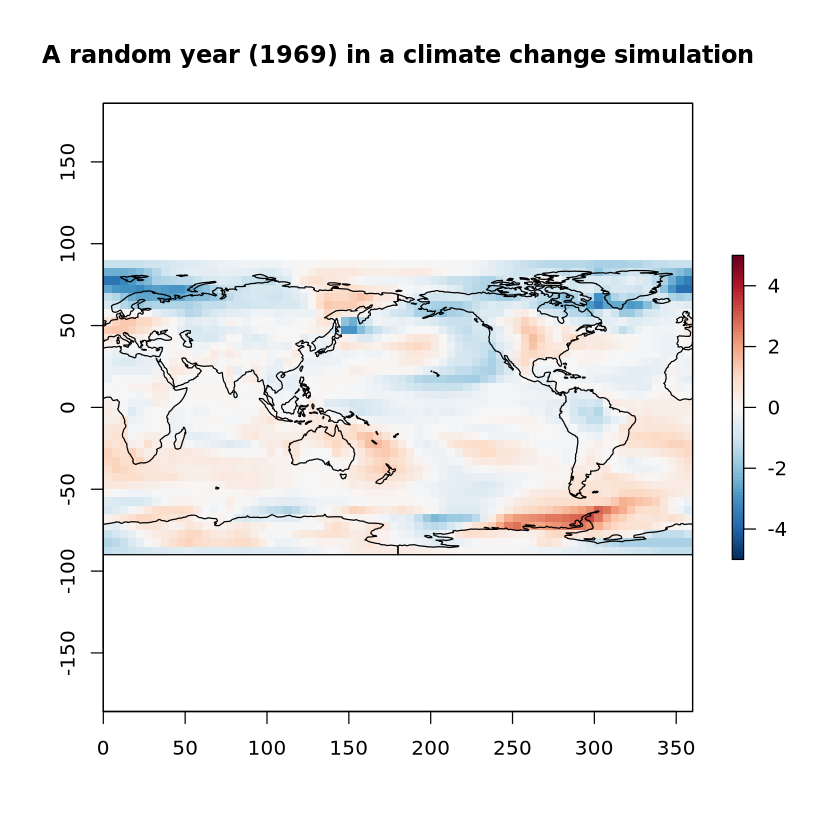

In [3]:
########################################################################
## 0.e. Visualize your dataset
########################################################################

# 1. plot random year's annual temperature anomalies (sample Nr. 2000):
par(mfrow=c(1,1))
plot.random.year <- raster.template 
values(plot.random.year) = c(matrix(LENS_tas_ann_train$X[2200,], 72, 36)[,36:1])
plot(plot.random.year, col = col.seq, zlim = c(-5,5), main = "A random year (1969) in a climate change simulation")
lines(land.polygon)

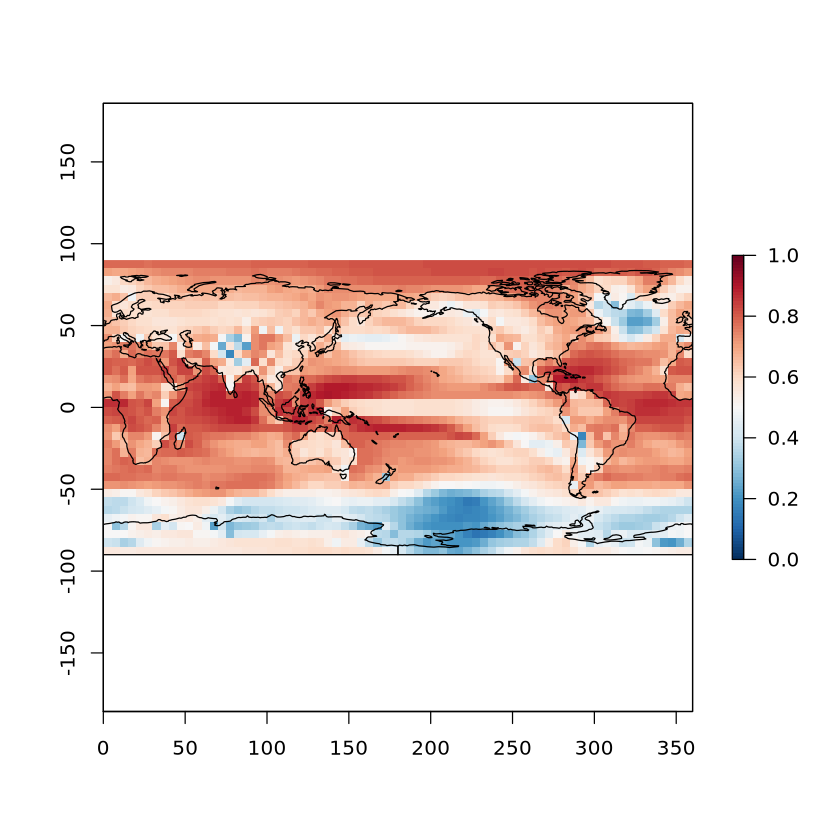

In [4]:
# 2. Correlations between each grid cell and the target "forced response"
mar.cor = apply(X = LENS_tas_ann_train$X, MARGIN=2, FUN=function(x) cor(x, LENS_tas_ann_train$Y$fraw))

plot.mar.cor <- raster.template 
values(plot.mar.cor) = c(matrix(mar.cor, 72, 36)[,36:1])
plot(plot.mar.cor, col = col.seq, zlim = c(0,1))
lines(land.polygon)

[1] 1
[1] 2
[1] 3
[1] 4
[1] 5
[1] 6


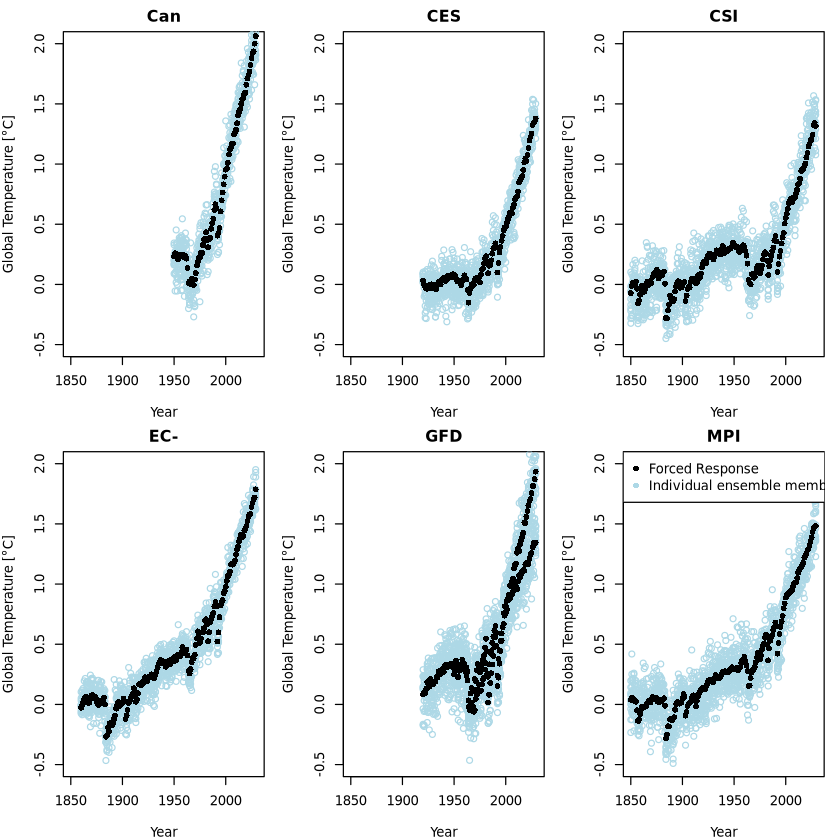

In [5]:
# 3. forced response and year for each ensemble member:
par(mfrow=c(2,3), mar=c(4,4,2,1))

for (i in 1:length(unique(LENS_tas_ann_train$M$modcl))) {
  print(i)
  ix=which(LENS_tas_ann_train$M$modcl == unique(LENS_tas_ann_train$M$modcl)[i])
  
  plot(c(1,1), xlim = c(1850, 2030), ylim = c(-0.5, 2), xlab = "Year", ylab = "Global Temperature [°C]", main = unique(LENS_tas_ann_train$M$modcl)[i])
  points(x = LENS_tas_ann_train$Y$year[ix], y = LENS_tas_ann_train$Y$AGMT[ix], col = "lightblue")
  points(x = LENS_tas_ann_train$Y$year[ix], y = LENS_tas_ann_train$Y$fraw[ix], pch = 16)
}
legend("topleft", c("Forced Response", "Individual ensemble members"), pch = 16, col = c("black", "lightblue"))

## Apply Model Project 2: Estimation of the state of forced climate change from annual temperature maps

Simple prediction workflow using multiple linear regression

In [6]:
########################################################################
########################################################################
## 1. Simple prediction workflow using multiple linear regression
########################################################################
########################################################################

########################################################################
## 1.a. Setup of training data & feature selection
########################################################################

# 1. Perform simple randomized feature selection:
set.seed(seed = 5)
grid.ix = sort(sample(x = 1:2592, size = 20, replace = F, prob = LENS_tas_ann_train$coord$areaw))

# 2. Generate data frames for OLS fit:
train.DF = data.frame(y=LENS_tas_ann_train$Y$fraw, X = LENS_tas_ann_train$X[,grid.ix])
train.DF2 = data.frame(y=LENS_tas_ann_train$Y$year, X = LENS_tas_ann_train$X[,grid.ix])

In [7]:
########################################################################
## 1.b. Fit OLS models for both target metrics
########################################################################

# 3 Fit OLS for both target metrics using all data
# (you may not want to use the same data for fitting and evaluation with statistical learning methods - split into train/test data or cross-vali):
my.OLS.mod = lm(y ~ ., data = train.DF)
my.OLS.pred = predict(object = my.OLS.mod, newdata = data.frame(X = LENS_tas_ann_train$X[,grid.ix]))
my.OLS.MSE = MSE(obs = LENS_tas_ann_train$Y$fraw, sim = my.OLS.pred)
my.OLS.R2 = cor(LENS_tas_ann_train$Y$fraw, my.OLS.pred) ^ 2

my.OLS2.mod = lm(y ~ ., data = train.DF2)
my.OLS2.pred = predict(object = my.OLS2.mod, newdata = data.frame(X = LENS_tas_ann_train$X[,grid.ix]))
my.OLS2.MSE = MSE(obs = LENS_tas_ann_train$Y$year, sim = my.OLS2.pred)
my.OLS2.R2 = cor(LENS_tas_ann_train$Y$year, my.OLS2.pred) ^ 2

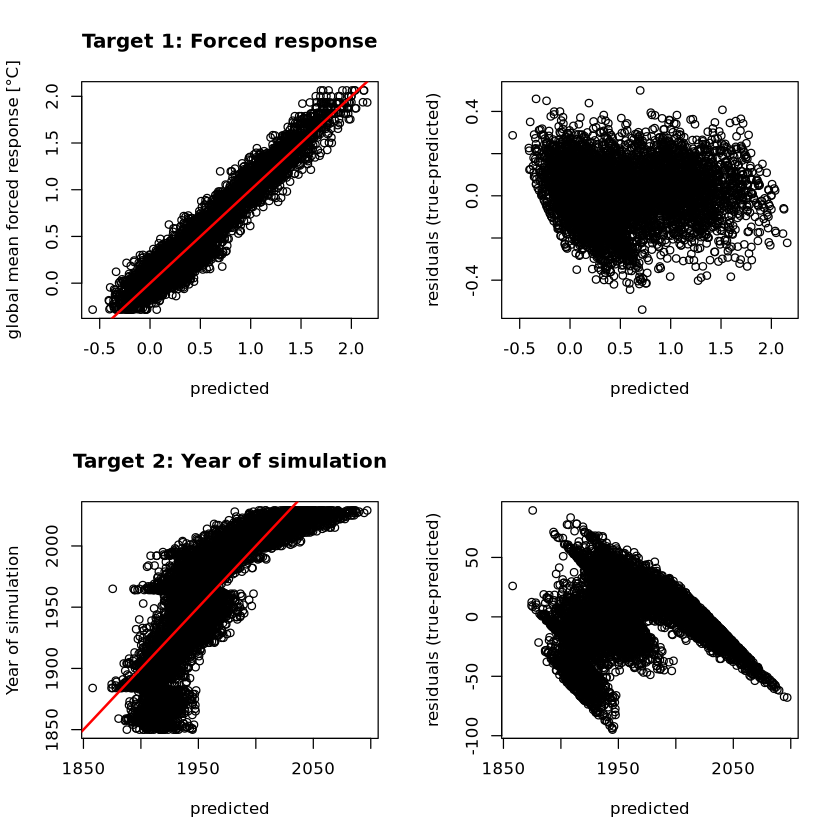

In [8]:
########################################################################
## 1.c. Visualize my predictions:
########################################################################

# upper row: predictions of global mean temperature forced response
# lower row: predictions of the year from which simulations comes
par(mfrow=c(2,2))
plot(my.OLS.pred, LENS_tas_ann_train$Y$fraw, xlab = "predicted", ylab = "global mean forced response [°C]", main = "Target 1: Forced response")
abline(0, 1, col = "red", lwd = 2)
plot(my.OLS.pred, LENS_tas_ann_train$Y$fraw - my.OLS.pred, xlab = "predicted", ylab = "residuals (true-predicted)")

plot(my.OLS2.pred, LENS_tas_ann_train$Y$year, xlab = "predicted", ylab = "Year of simulation", main = "Target 2: Year of simulation")
abline(0, 1, col = "red", lwd = 2)
plot(my.OLS2.pred, LENS_tas_ann_train$Y$year - my.OLS2.pred, xlab = "predicted", ylab = "residuals (true-predicted)")

In [9]:
########################################################################
## 1.d. Derive predictions for unseen test dataset.
########################################################################


my.OLS.fraw.pred = predict(object = my.OLS.mod, newdata = data.frame(X = LENS_tas_ann_test$X[,grid.ix]))
my.OLS.year.pred = predict(object = my.OLS2.mod, newdata = data.frame(X = LENS_tas_ann_test$X[,grid.ix]))

# save my predictions:
# save(c("my.OLS.fraw.pred", "my.OLS.year.pred"), file = "groupX.prediction.RData")

## Now it's your turn!

In [ ]:
# start coding here ...

**Check for how many years each model has data:**

In [16]:
library(dplyr)

LENS_tas_ann_train$M |>
  group_by(mod) |>
  summarise(
    n_years   = n_distinct(year),
    year_min  = min(year),
    year_max  = max(year),
    .groups = "drop"
  )

mod,n_years,year_min,year_max
<chr>,<int>,<chr>,<chr>
CESM1-CAM5,110,1920,2029
CSIRO-Mk3-6-0,180,1850,2029
CanESM2,80,1950,2029
EC-EARTH,170,1860,2029
GFDL-CM3,110,1920,2029
GFDL-ESM2M,80,1950,2029
MPI-ESM,180,1850,2029


## Ridge regression

In [17]:
library(glmnet)
library(raster)
library(RColorBrewer)
library(rworldmap)
library(ncdf4)

Loading required package: Matrix

Loaded glmnet 5.0



### Prepare data

In [31]:
train.df.fraw = data.frame(y=LENS_tas_ann_train$Y$fraw, X = LENS_tas_ann_train$X)
train.df.year = data.frame(y=LENS_tas_ann_train$Y$year, X = LENS_tas_ann_train$X)

In [32]:
str(train.df.fraw)

'data.frame':	9100 obs. of  2593 variables:
 $ y     : num  0.233 0.26 0.255 0.229 0.207 ...
 $ X.1   : num  0.0354 -0.6857 0.3523 0.9861 1.3746 ...
 $ X.2   : num  0.046 -0.631 0.414 1.05 1.474 ...
 $ X.3   : num  -0.0745 -0.7066 0.3463 0.9582 1.4474 ...
 $ X.4   : num  -0.0654 -0.6425 0.4264 0.9911 1.5623 ...
 $ X.5   : num  -0.0714 -0.5882 0.4996 0.9985 1.6471 ...
 $ X.6   : num  -0.079 -0.531 0.576 1.02 1.729 ...
 $ X.7   : num  -0.127 -0.525 0.595 0.994 1.761 ...
 $ X.8   : num  -0.178 -0.518 0.614 0.978 1.794 ...
 $ X.9   : num  -0.174 -0.47 0.682 1.014 1.877 ...
 $ X.10  : num  -0.196 -0.458 0.717 1.024 1.935 ...
 $ X.11  : num  -0.211 -0.444 0.761 1.043 1.991 ...
 $ X.12  : num  -0.27 -0.524 0.709 0.983 1.959 ...
 $ X.13  : num  -0.221 -0.549 0.72 0.992 1.975 ...
 $ X.14  : num  -0.132 -0.593 0.693 1.01 1.962 ...
 $ X.15  : num  -0.00262 -0.63009 0.64797 1.03812 1.93878 ...
 $ X.16  : num  0.118 -0.652 0.587 1.063 1.891 ...
 $ X.17  : num  0.236 -0.652 0.528 1.083 1.841 ...
 $ 

### First model run

with single random train/test split


In [53]:
n_obs <- nrow(train.df.fraw)
n_pred <- ncol(train.df.fraw) - 1
n_test <- floor(n_obs * 0.3)  # 30%
set.seed(123)
test_idx <- sample(seq_len(n_obs), size = n_test)
print(test_idx)

   [1] 2463 2511 8718 2986 1842 3371 4761 6746 2757 5107 2888 6170 2567 2980
  [15] 1614  555 4469 7789 1047 7067 3004 3207 7989 3995 8358  217 8157 6216
  [29] 8780 1599 4237 3937 4089 2907  294 8469   41 8508 7391 6672 7284 2504
  [43] 6742 8944 8566 6129 4612 2117 6134  755 6553 5428 7127 3358 3980 3230
  [57] 5603 4576 3783 7831 5967 7816 1386 4706 2378 4044  686 6078 5027 6387
  [71] 7281 4715  151 6810 8174 6911 2208 1029 8518 7448 7735 8011 1956 8172
  [85] 5358 5884 4093  985 6183  986 4233 1584 4685 7864 4776 6644 9013 8536
  [99] 7478 2507  195 3124 6678 4650 2132 3464 3949 7757 2758 3833  712 5370
 [113] 3501 3069 8720 4055  473 6098 1149 2037 2313 7741 8650 1078 5015 5658
 [127] 6379 1313  185 7933  413 4723 1333 4875  564 3799 4256 3581 3129 6601
 [141] 4713 8549  279 4366 6790 6491 3201 2266  618 1905 8529  539 3625 6868
 [155] 3462 5618 6815 7005 6801 3008 6804 2211 2286 5793 7684 9036 5509 4213
 [169] 7826 1706 7879 8081  988 9078 4807 5588 3809 7426 2225 1165 6083 7634

#### For forced warming

In [46]:
lambda.ridge  = 0.75
our.ridge.fit = glmnet(x = train.df.fraw[-test_idx,-1],
                       y = train.df.fraw$y[-test_idx],
                       family="gaussian", alpha=0, standardize=T, lambda = lambda.ridge)

our.ridge.prediction = predict(our.ridge.fit, as.matrix(train.df.fraw[test_idx,-1]), lambda.ridge)
sprintf("R2 value of prediction on test dataset: %.2f",
        cor(c(our.ridge.prediction), train.df.fraw$y[test_idx])^2)
sprintf("MSE value of prediction on test dataset: %.4f",
        MSE(c(our.ridge.prediction), train.df.fraw$y[test_idx]))

[1] "R2 value of prediction on test dataset: 0.98"

[1] "MSE value of prediction on test dataset: 0.0048"

#### Same for year

In [48]:
lambda.ridge  = 0.75
our.ridge.fit = glmnet(x = train.df.year[-test_idx,-1],
                       y = train.df.year$y[-test_idx],
                       family="gaussian", alpha=0, standardize=T, lambda = lambda.ridge)
our.ridge.prediction = predict(our.ridge.fit, as.matrix(train.df.year[test_idx,-1]), lambda.ridge)
sprintf("R2 value of prediction on test dataset: %.2f",
        cor(c(our.ridge.prediction), train.df.year$y[test_idx])^2)
sprintf("MSE value of prediction on test dataset: %.4f",
        MSE(c(our.ridge.prediction), train.df.year$y[test_idx]))
sprintf("MAE value of prediction on test dataset: %.2f",
        sqrt(MSE(c(our.ridge.prediction), train.df.year$y[test_idx])))

[1] "R2 value of prediction on test dataset: 0.89"

[1] "MSE value of prediction on test dataset: 250.1034"

[1] "MAE value of prediction on test dataset: 15.81"

### Hyperparameter tuning

$\rightarrow$ find the ideal $\lambda$

In [65]:
## Define range of lambdas for which beta coefficients should be estiamted
lambda_exponent <- seq(-8,5,length.out=101)
lambda_vec      <- 10^lambda_exponent
print(lambda_vec)

  [1] 1.000000e-08 1.348963e-08 1.819701e-08 2.454709e-08 3.311311e-08
  [6] 4.466836e-08 6.025596e-08 8.128305e-08 1.096478e-07 1.479108e-07
 [11] 1.995262e-07 2.691535e-07 3.630781e-07 4.897788e-07 6.606934e-07
 [16] 8.912509e-07 1.202264e-06 1.621810e-06 2.187762e-06 2.951209e-06
 [21] 3.981072e-06 5.370318e-06 7.244360e-06 9.772372e-06 1.318257e-05
 [26] 1.778279e-05 2.398833e-05 3.235937e-05 4.365158e-05 5.888437e-05
 [31] 7.943282e-05 1.071519e-04 1.445440e-04 1.949845e-04 2.630268e-04
 [36] 3.548134e-04 4.786301e-04 6.456542e-04 8.709636e-04 1.174898e-03
 [41] 1.584893e-03 2.137962e-03 2.884032e-03 3.890451e-03 5.248075e-03
 [46] 7.079458e-03 9.549926e-03 1.288250e-02 1.737801e-02 2.344229e-02
 [51] 3.162278e-02 4.265795e-02 5.754399e-02 7.762471e-02 1.047129e-01
 [56] 1.412538e-01 1.905461e-01 2.570396e-01 3.467369e-01 4.677351e-01
 [61] 6.309573e-01 8.511380e-01 1.148154e+00 1.548817e+00 2.089296e+00
 [66] 2.818383e+00 3.801894e+00 5.128614e+00 6.918310e+00 9.332543e+00
 [71] 

In [66]:
## Calculate beta estimates for different lambda values:

# only use 50 predictors (to make faster)
set.seed(123)
feature_samples <- sample(seq(n_pred)+1, size=50)

betas_ridge_fraw <- cv.glmnet(x = as.matrix(train.df.fraw[-test_idx,feature_samples]), 
                              y = as.matrix(train.df.fraw$y[-test_idx]),
                              family="gaussian", alpha=0, standardize=T,
                              lambda = lambda_vec)$glmnet.fit$beta[,length(lambda_vec):1]

betas_ridge_year <- cv.glmnet(x = as.matrix(train.df.year[-test_idx,feature_samples]), 
                              y = as.matrix(train.df.year$y[-test_idx]),
                              family="gaussian", alpha=0, standardize=T,
                              lambda = lambda_vec)$glmnet.fit$beta[,length(lambda_vec):1]

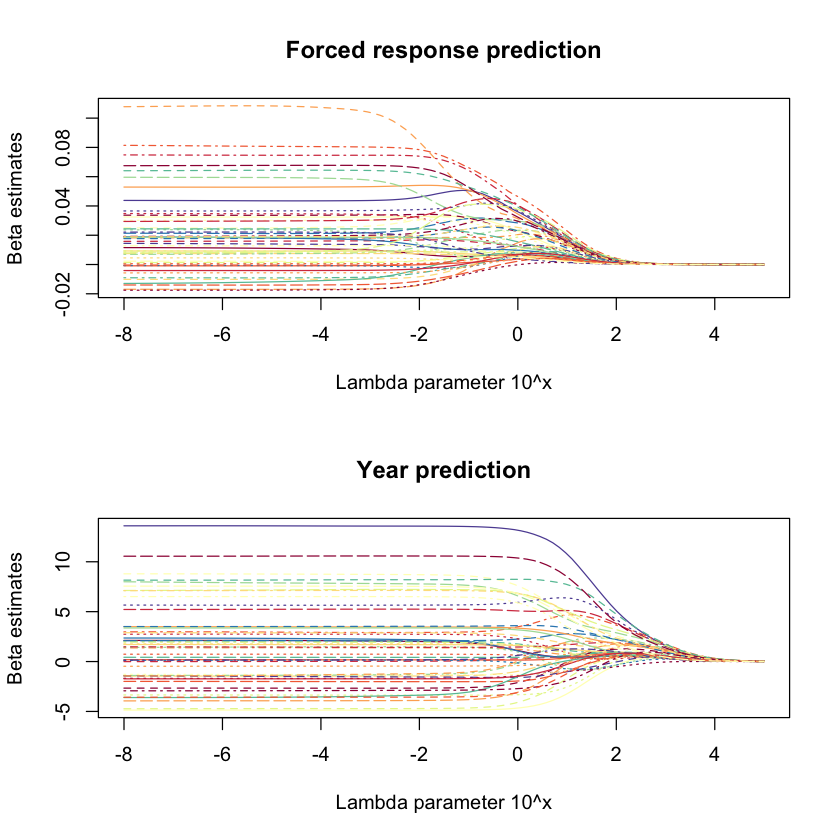

In [67]:
## Plot Ridge estimates for different lambdas:
cols <- colorRampPalette(brewer.pal(n = 11, name = "Spectral"))(11) 

par(mfrow=c(2,1))
matplot(x=lambda_exponent, t(betas_ridge_fraw), type="l", ylim=range(betas_ridge_fraw),
        xlab="Lambda parameter 10^x", ylab="Beta estimates", main="Forced response prediction", col=cols)
matplot(x=lambda_exponent, t(betas_ridge_year), type="l", ylim=range(betas_ridge_year),
        xlab="Lambda parameter 10^x", ylab="Beta estimates", main="Year prediction", col=cols)

### Find optimal beta via 10-fold cross-validation

In [68]:
ridge.model.fraw = cv.glmnet(x = as.matrix(train.df.fraw[,-1]), 
                             y = as.matrix(train.df.fraw$y), 
                             family="gaussian", alpha = 0, 
                             nfolds = 10, standardize = T, lambda=lambda_vec)

ridge.model.year = cv.glmnet(x = as.matrix(train.df.year[,-1]), 
                             y = as.matrix(train.df.year$y), 
                             family="gaussian", alpha = 0, 
                             nfolds = 10, standardize = T, lambda=lambda_vec)

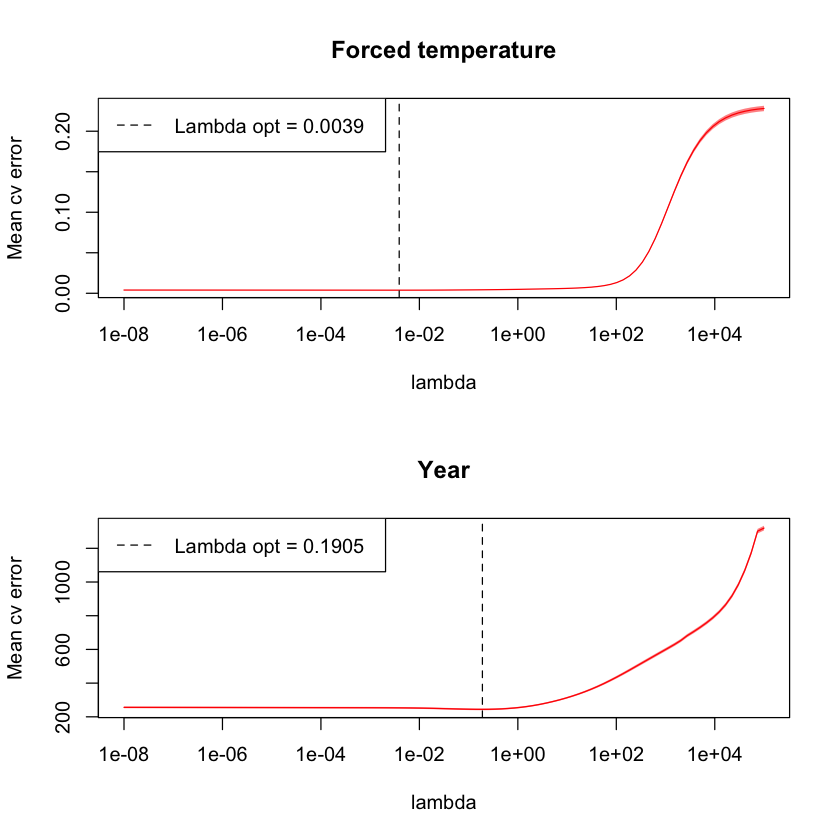

In [70]:
# plot
par(mfrow=c(2,1))
plot(ridge.model.fraw$lambda, ridge.model.fraw$cvm, type="l", log="x",col="red",
     ylab="Mean cv error", xlab="lambda", main="Forced temperature",
     ylim=c(min(ridge.model.fraw$cvlo),max(ridge.model.fraw$cvup)))
polygon(c(ridge.model.fraw$lambda,rev(ridge.model.fraw$lambda)),
        c(ridge.model.fraw$cvlo,rev(ridge.model.fraw$cvup)),
        col=rgb(1,0,0,0.5),border=NA)
abline(v=ridge.model.fraw$lambda[which.min(ridge.model.fraw$cvm)],lty="dashed")
legend("topleft",legend=sprintf("Lambda opt = %.4f", ridge.model.fraw$lambda[which.min(ridge.model.fraw$cvm)]),
      lty="dashed")

plot(ridge.model.year$lambda, ridge.model.year$cvm, type="l", log="x",col="red",
     ylab="Mean cv error", xlab="lambda", main="Year",
     ylim=c(min(ridge.model.year$cvlo),max(ridge.model.year$cvup)))
polygon(c(ridge.model.year$lambda,rev(ridge.model.year$lambda)),
        c(ridge.model.year$cvlo,rev(ridge.model.year$cvup)),
        col=rgb(1,0,0,0.5),border=NA)
abline(v=ridge.model.year$lambda[which.min(ridge.model.year$cvm)],lty="dashed")
legend("topleft",legend=sprintf("Lambda opt = %.4f", ridge.model.year$lambda[which.min(ridge.model.year$cvm)]),
      lty="dashed")

In [ ]:
# ridge.prediction = predict(ridge.model, X[test.set.idx,], "lambda.min") 

# sprintf("R2 value of ridge prediction on test dataset: %.2f",
#         cor(c(ridge.prediction), Y[test.set.idx])^2)
# sprintf("MSE value of ridge prediction on test dataset: %.2f",
#         MSE(c(ridge.prediction), Y[test.set.idx]))

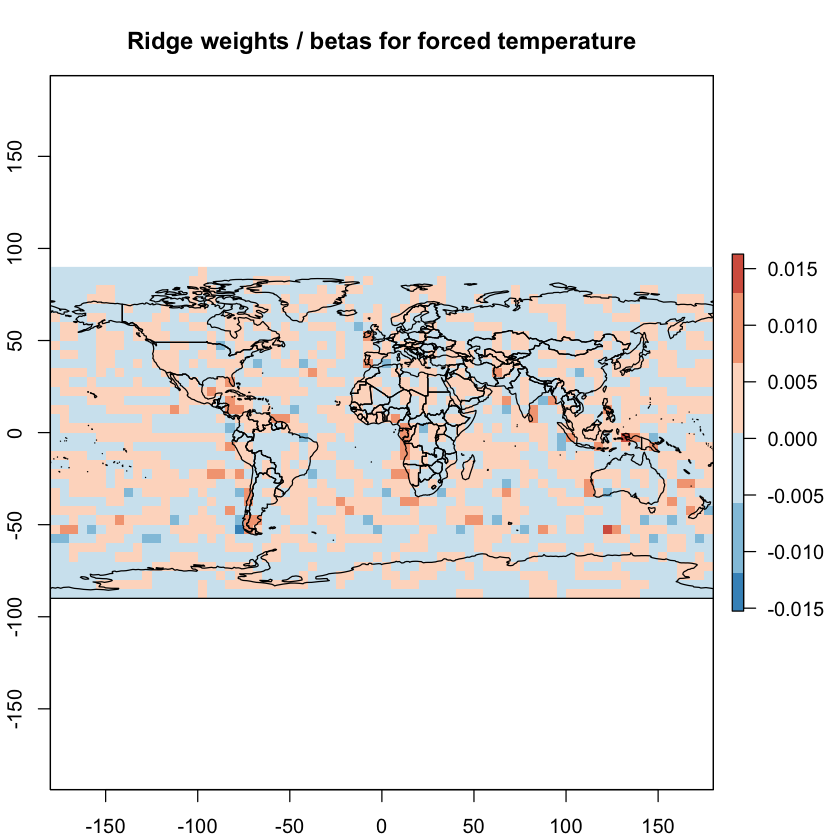

In [84]:
## Define color palette:
col.div    <- colorRampPalette(rev(brewer.pal(n = 10, name = "RdBu")))(10)

## 2. Extract beta coefficients at the optimal lambda
##    coef() returns a sparse matrix: row 1 = intercept, rows 2:end = predictors
##    Converting to numeric vector and dropping the intercept with [-1]
betas <- as.numeric(coef(ridge.model.fraw, s = "lambda.1se"))[-1]

## 3. Get pixel coordinates (x = lon, y = lat)
coords <- LENS_tas_ann_train$coord[, -3]

## 4. Build an empty raster grid aligned to your pixel locations
spatial_raster <- raster(
  SpatialPixels(
    SpatialPoints(
      coords      = coords,
      proj4string = CRS("+proj=longlat")
    )
  )
)

## 5. For each coordinate, find which raster cell it belongs to,
##    then write the corresponding beta into that cell.
##    This is order-independent — no assumption about row ordering needed.
cell_idx <- cellFromXY(spatial_raster, as.matrix(coords))
values(spatial_raster)[cell_idx] <- betas

## 6. Set exact zeros to NA so they don't get a color in the plot
values(spatial_raster)[values(spatial_raster) == 0] <- NA

## After assigning values and masking zeros, rotate the raster
## from 0–360° to –180–180° longitude so it lines up with countriesCoarse
plot.raster <- rotate(spatial_raster)

## 7. Plot
par(mfrow = c(1, 1), mar = c(2, 2, 3, 1))
plot(plot.raster,
     col  = col.div[3:8], # limit color palette (no extreme colors)
     main = "Ridge weights / betas for global mean forced temperature")
plot(countriesCoarse, add = TRUE)

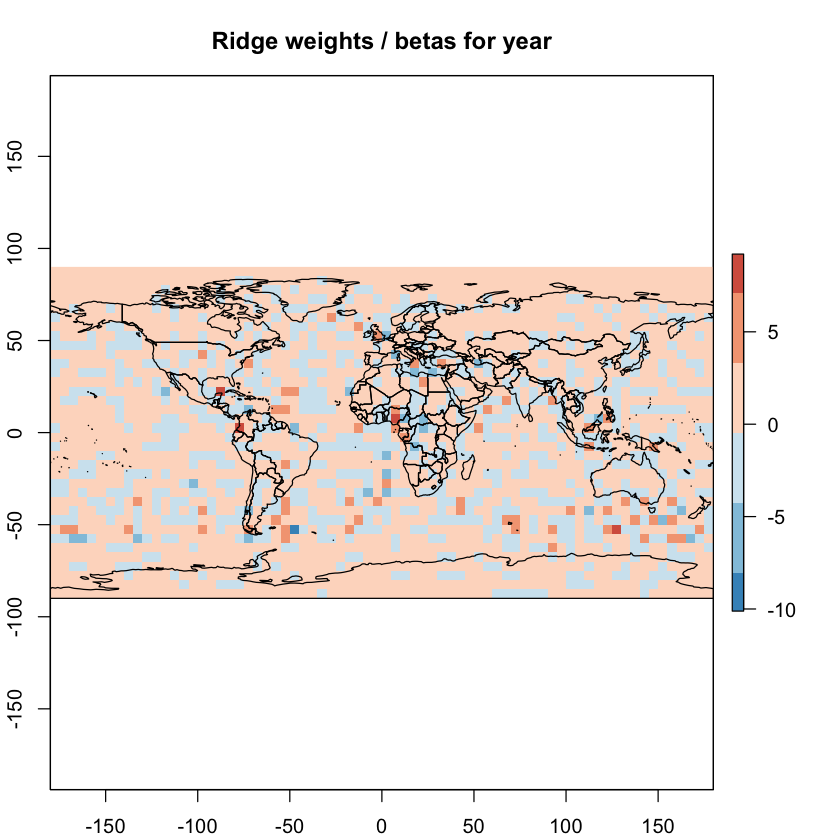

In [85]:
## Define color palette:
col.div    <- colorRampPalette(rev(brewer.pal(n = 10, name = "RdBu")))(10)

## 2. Extract beta coefficients at the optimal lambda
##    coef() returns a sparse matrix: row 1 = intercept, rows 2:end = predictors
##    Converting to numeric vector and dropping the intercept with [-1]
betas <- as.numeric(coef(ridge.model.year, s = "lambda.1se"))[-1]

## 3. Get pixel coordinates (x = lon, y = lat)
coords <- LENS_tas_ann_train$coord[, -3]

## 4. Build an empty raster grid aligned to your pixel locations
spatial_raster <- raster(
  SpatialPixels(
    SpatialPoints(
      coords      = coords,
      proj4string = CRS("+proj=longlat")
    )
  )
)

## 5. For each coordinate, find which raster cell it belongs to,
##    then write the corresponding beta into that cell.
##    This is order-independent — no assumption about row ordering needed.
cell_idx <- cellFromXY(spatial_raster, as.matrix(coords))
values(spatial_raster)[cell_idx] <- betas

## 6. Set exact zeros to NA so they don't get a color in the plot
values(spatial_raster)[values(spatial_raster) == 0] <- NA

## After assigning values and masking zeros, rotate the raster
## from 0–360° to –180–180° longitude so it lines up with countriesCoarse
plot.raster <- rotate(spatial_raster)

## 7. Plot
par(mfrow = c(1, 1), mar = c(2, 2, 3, 1))
plot(plot.raster,
     col  = col.div[3:8], # limit color palette (no extreme colors)
     main = "Ridge weights / betas for year")
plot(countriesCoarse, add = TRUE)

Can add:
- 1-1 plot for predicted vs. observed $\rightarrow$ expect better prediction towards end of century
- could you do a spatial cross-validation to check which regions are most important for prediction? or even just general finding that/if target variables have more/less relevant regions (linked to internal and model variability)